## 📦 Step 1: Import Libraries

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## 📂 Step 2: Load Dataset

> We use the classic **Mall Customers** dataset. If you have the CSV, update the path below. Otherwise, a synthetic version is generated automatically.

In [24]:
df = pd.read_csv('../data/Mall_Customers.csv')

# Basic sanity checks
print(f"Dataset shape: {df.shape}")
print(df.head(10))

# Optional: inspect structure
print("\nColumn Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

Dataset shape: (200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
5           6  Female   22                  17                      76
6           7  Female   35                  18                       6
7           8  Female   23                  18                      94
8           9    Male   64                  19                       3
9          10  Female   30                  19                      72

Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------

## 🔍 Step 3: Exploratory Data Analysis

In [25]:
print('=== Dataset Info ===')
print(df.info())
print('\n=== Descriptive Statistics ===')
df.describe()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
None

=== Descriptive Statistics ===


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


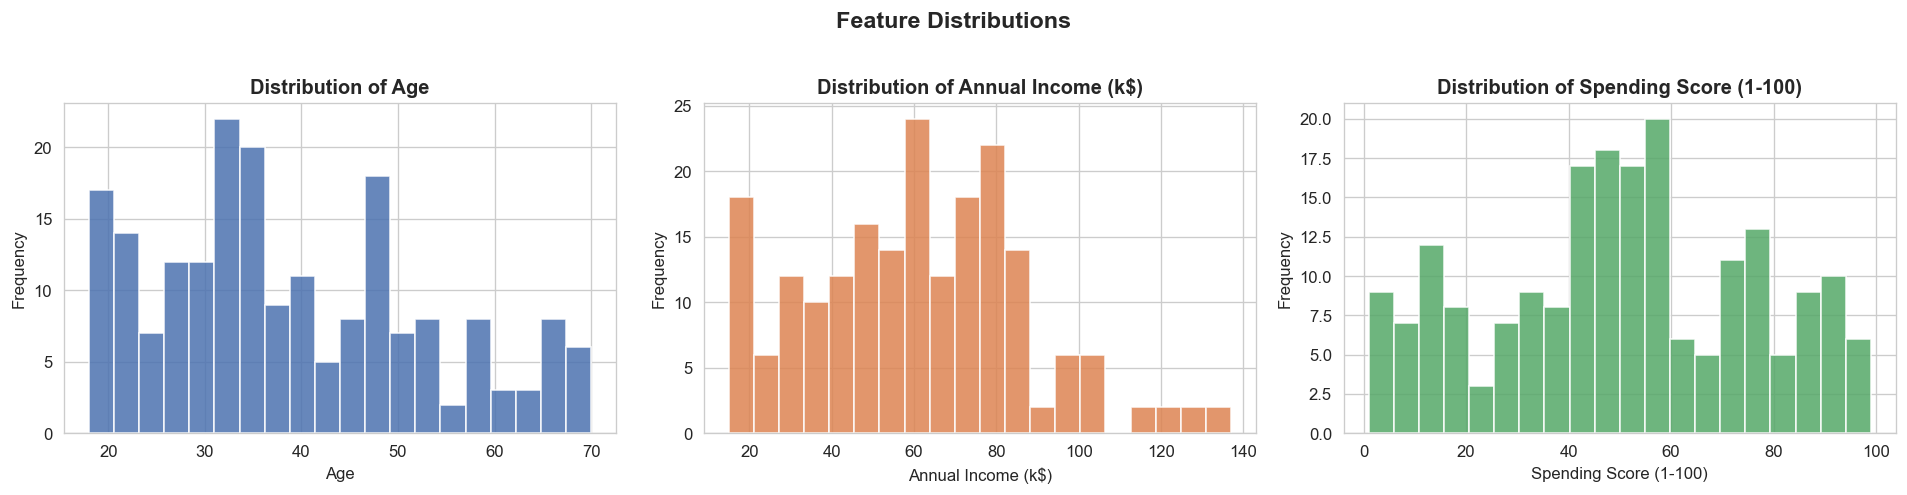

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, feat, col in zip(axes, features, colors):
    ax.hist(df[feat], bins=20, color=col, edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribution of {feat}', fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

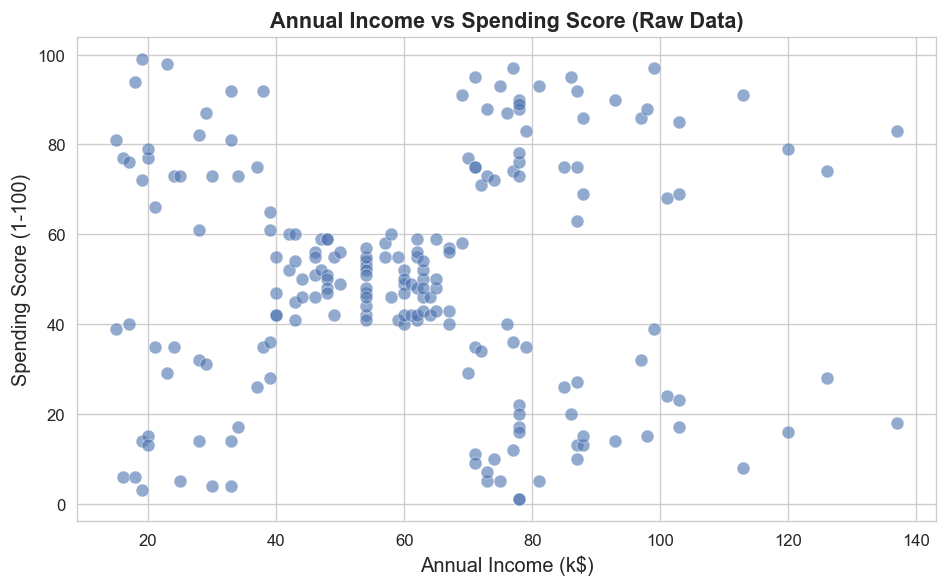

In [27]:
# Raw scatter — Annual Income vs Spending Score
plt.figure(figsize=(8, 5))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            alpha=0.6, edgecolors='white', linewidth=0.4, s=60, color='#4C72B0')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title('Annual Income vs Spending Score (Raw Data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## ⚙️ Step 4: Preprocessing & Scaling

In [28]:
# Select features (use 2D for easy visualisation; 3D optionally)
features_2d = ['Annual Income (k$)', 'Spending Score (1-100)']
features_3d = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

X_raw = df[features_2d].values

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f'Feature matrix shape : {X.shape}')
print(f'Mean after scaling   : {X.mean(axis=0).round(6)}')
print(f'Std  after scaling   : {X.std(axis=0).round(6)}')

Feature matrix shape : (200, 2)
Mean after scaling   : [-0. -0.]
Std  after scaling   : [1. 1.]


## 📊 Step 5: Choose Number of Components (BIC / AIC)

> We sweep over different numbers of components and compare **AIC** and **BIC** scores to find the optimal `n_components`.

Best n_components by BIC: 5
Best n_components by AIC: 10


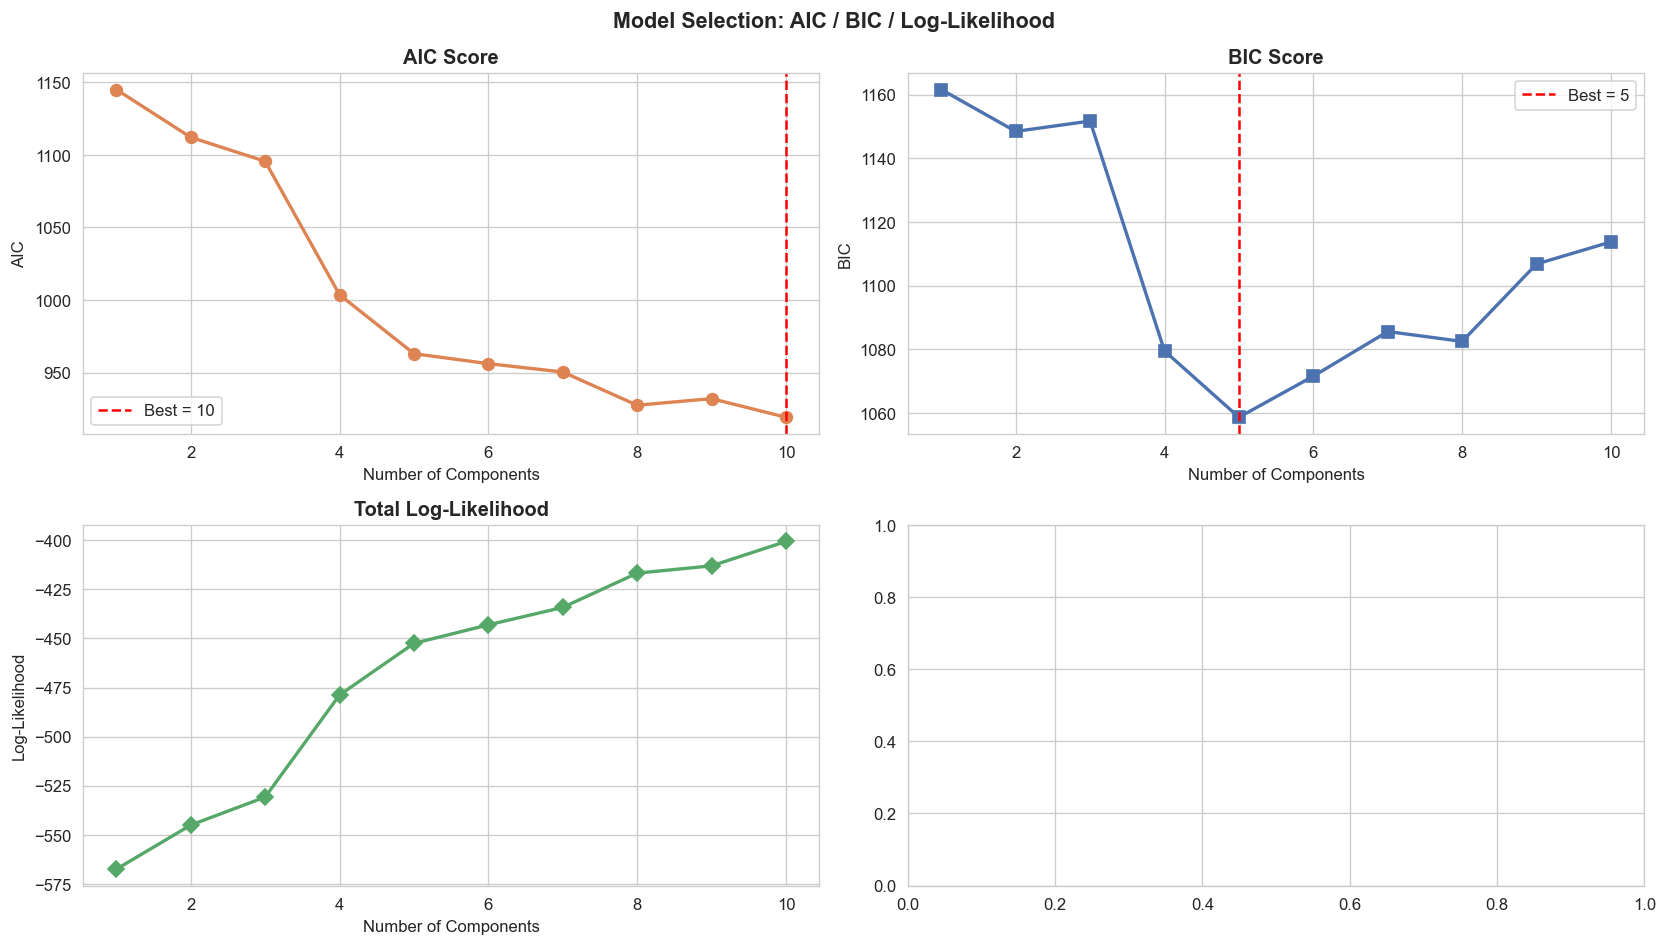

In [29]:
n_range = range(1, 11)
aic_scores, bic_scores, ll_scores = [], [], []

for n in n_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42, n_init=5)
    gmm.fit(X)
    aic_scores.append(gmm.aic(X))
    bic_scores.append(gmm.bic(X))
    ll_scores.append(gmm.score(X) * len(X))   # total log-likelihood

best_n_bic = n_range.start + np.argmin(bic_scores)
best_n_aic = n_range.start + np.argmin(aic_scores)
print(f'Best n_components by BIC: {best_n_bic}')
print(f'Best n_components by AIC: {best_n_aic}')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# AIC
axes[0][0].plot(n_range, aic_scores, 'o-', color='#DD8452', lw=2, ms=7)
axes[0][0].axvline(best_n_aic, color='red', linestyle='--', label=f'Best = {best_n_aic}')
axes[0][0].set_title('AIC Score', fontweight='bold')
axes[0][0].set_xlabel('Number of Components')
axes[0][0].set_ylabel('AIC')
axes[0][0].legend()

# BIC
axes[0][1].plot(n_range, bic_scores, 's-', color='#4C72B0', lw=2, ms=7)
axes[0][1].axvline(best_n_bic, color='red', linestyle='--', label=f'Best = {best_n_bic}')
axes[0][1].set_title('BIC Score', fontweight='bold')
axes[0][1].set_xlabel('Number of Components')
axes[0][1].set_ylabel('BIC')
axes[0][1].legend()

# Log-Likelihood
axes[1][0].plot(n_range, ll_scores, 'D-', color='#55A868', lw=2, ms=7)
axes[1][0].set_title('Total Log-Likelihood', fontweight='bold')
axes[1][0].set_xlabel('Number of Components')
axes[1][0].set_ylabel('Log-Likelihood')

plt.suptitle('Model Selection: AIC / BIC / Log-Likelihood', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🤖 Step 6: Fit Gaussian Mixture Model (Expectation-Maximisation)

In [ ]:
N_COMPONENTS = best_n_bic   # change manually if desired
 
gmm = GaussianMixture(
    n_components=N_COMPONENTS,
    covariance_type='full',   # full covariance → elliptical clusters
    max_iter=300,
    n_init=10,
    random_state=42
)
gmm.fit(X)

print(f'Number of EM iterations : {gmm.n_iter_}')
print(f'Converged               : {gmm.converged_}')
print(f'Log-Likelihood          : {gmm.score(X) * len(X):.4f}')
print(f'AIC                     : {gmm.aic(X):.4f}')
print(f'BIC                     : {gmm.bic(X):.4f}')

Number of EM iterations : 5
Converged               : True
Log-Likelihood          : -452.5005
AIC                     : 963.0010
BIC                     : 1058.6523


## 📈 Step 7: Predict Cluster Probabilities (Soft Clustering)

In [31]:
# Soft assignment: probability for each cluster
proba = gmm.predict_proba(X)          # shape: (n_samples, n_components)

# Hard assignment: cluster with highest probability
gmm_labels = gmm.predict(X)

# Add to dataframe
df['GMM_Cluster'] = gmm_labels
for c in range(N_COMPONENTS):
    df[f'Prob_Cluster_{c}'] = proba[:, c]

df['Max_Probability'] = proba.max(axis=1)

print('=== First 10 rows with probabilities ===')
prob_cols = ['Annual Income (k$)', 'Spending Score (1-100)', 'GMM_Cluster', 'Max_Probability']
df[prob_cols].head(10)

=== First 10 rows with probabilities ===


,Annual Income (k$),Spending Score (1-100),GMM_Cluster,Max_Probability
0,15,39,4,0.999032
1,15,81,2,0.999790
2,16,6,4,0.999814
3,16,77,2,0.999694
4,17,40,4,0.998378
5,17,76,2,0.999592
6,18,6,4,0.999745
7,18,94,2,0.999677
8,19,3,4,0.999583
9,19,72,2,0.998373


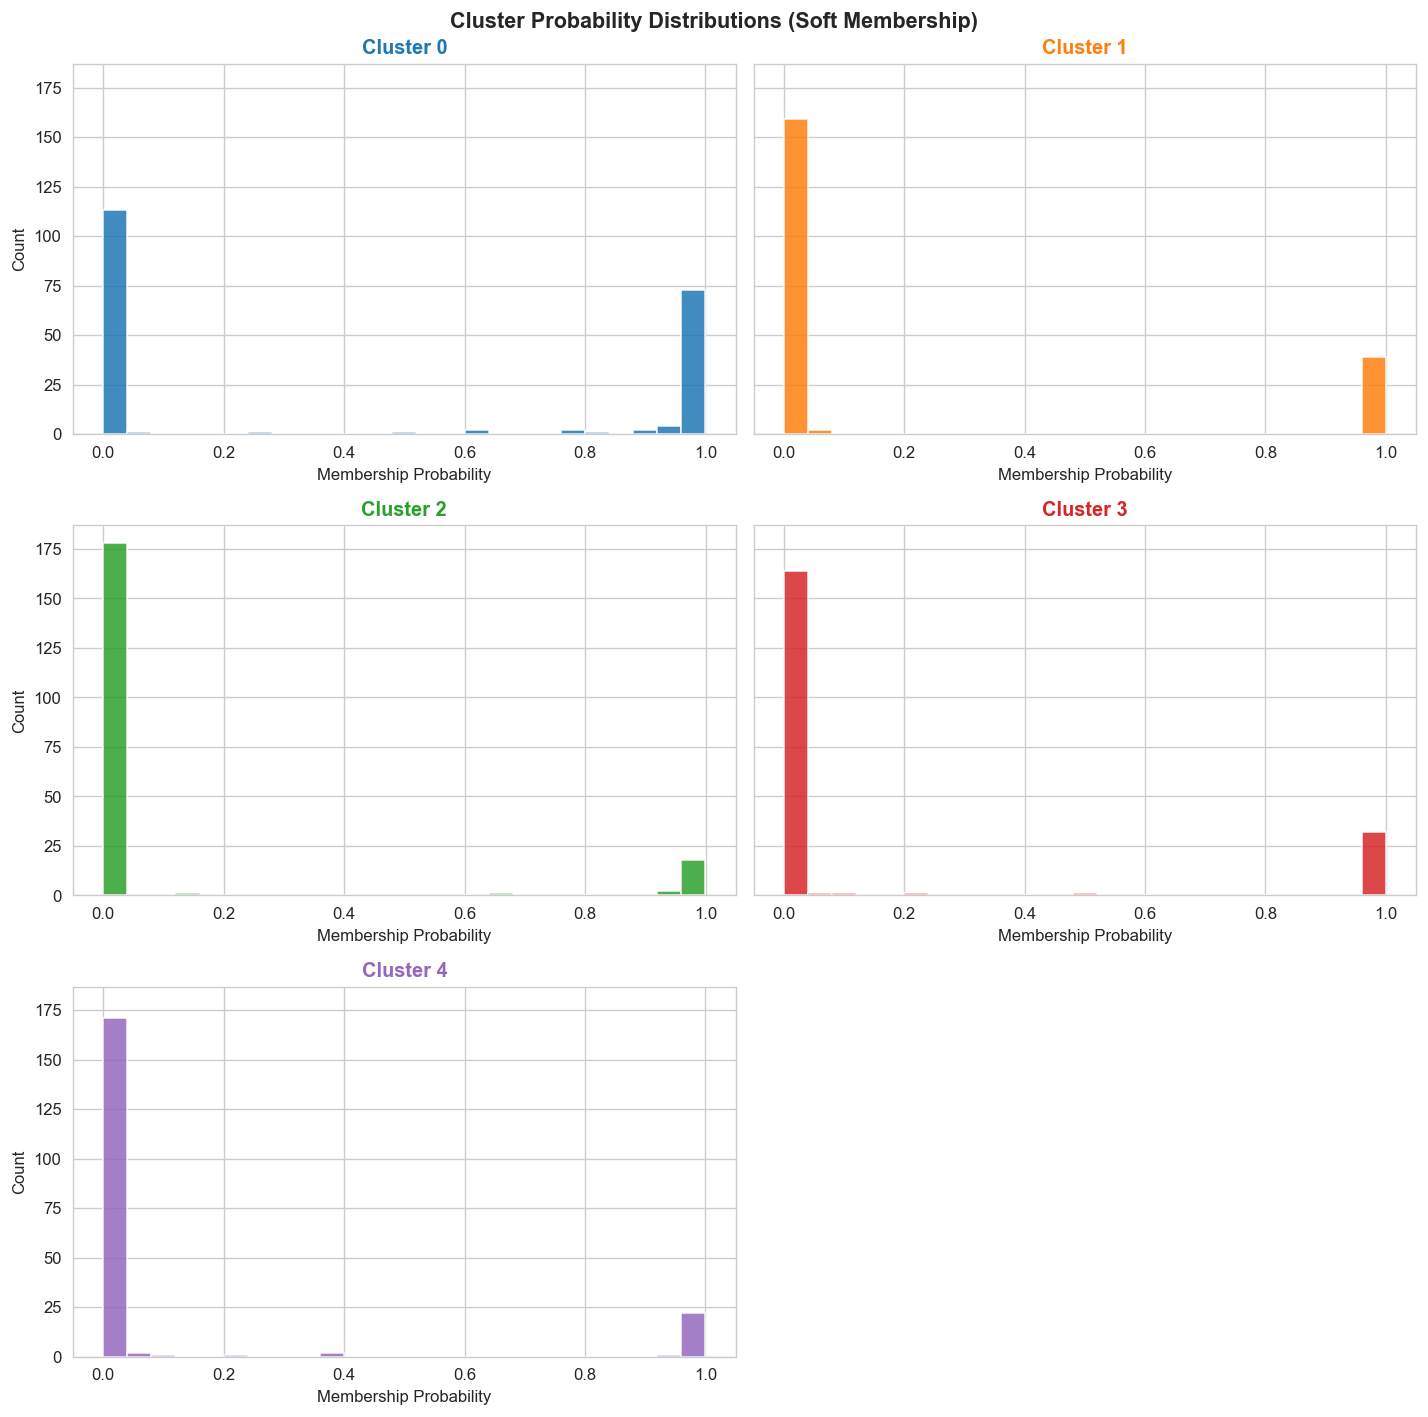

In [ ]:

fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharey=True)
axes = axes.flatten()  # flatten to 1D for easy looping

palette = sns.color_palette('tab10', N_COMPONENTS)

for i in range(N_COMPONENTS):
    ax = axes[i]
    ax.hist(proba[:, i], bins=25, color=palette[i], edgecolor='white', alpha=0.85)
    ax.set_title(f'Cluster {i}', fontweight='bold', color=palette[i])
    ax.set_xlabel('Membership Probability')
    if i % 2 == 0:  # first column
        ax.set_ylabel('Count')

# Hide unused subplots if N_COMPONENTS < 6
for j in range(N_COMPONENTS, len(axes)):
    axes[j].axis('off')

plt.suptitle('Cluster Probability Distributions (Soft Membership)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🗺️ Step 8: GMM Contour Plot (with Ellipses)

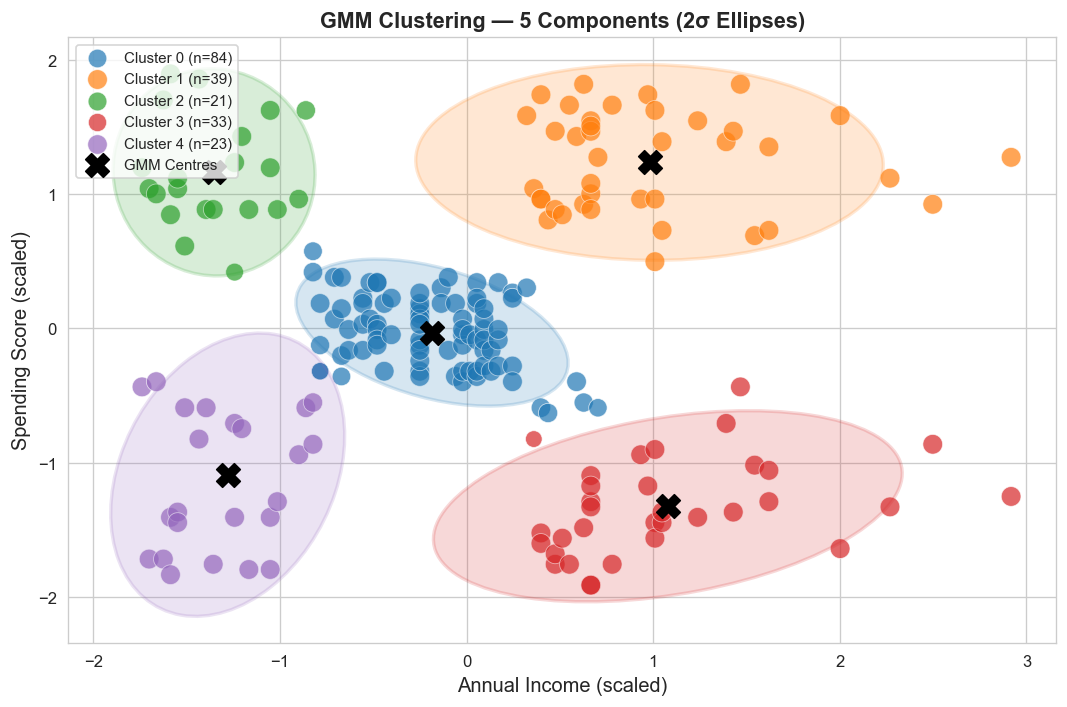

In [33]:
def draw_ellipse(ax, mean, cov, color, n_std=2.0, alpha=0.18):
    """Draw a covariance ellipse for a GMM component."""
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigvals)
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  facecolor=color, alpha=alpha, edgecolor=color, linewidth=2)
    ax.add_patch(ell)

palette = sns.color_palette('tab10', N_COMPONENTS)
fig, ax = plt.subplots(figsize=(9, 6))

# Scatter coloured by GMM cluster, sized by certainty
for i in range(N_COMPONENTS):
    mask = gmm_labels == i
    ax.scatter(X[mask, 0], X[mask, 1],
               color=palette[i], s=60 + 80*proba[mask, i],
               alpha=0.7, edgecolors='white', linewidth=0.5,
               label=f'Cluster {i} (n={mask.sum()})')
    draw_ellipse(ax, gmm.means_[i], gmm.covariances_[i], palette[i], n_std=2.0)

# Mark component centres
ax.scatter(gmm.means_[:, 0], gmm.means_[:, 1],
           marker='X', s=200, c='black', zorder=5, label='GMM Centres')

ax.set_xlabel('Annual Income (scaled)', fontsize=12)
ax.set_ylabel('Spending Score (scaled)', fontsize=12)
ax.set_title(f'GMM Clustering — {N_COMPONENTS} Components (2σ Ellipses)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## ⚔️ Step 9: Compare with K-Means Clustering

K-Means Inertia: 65.5684


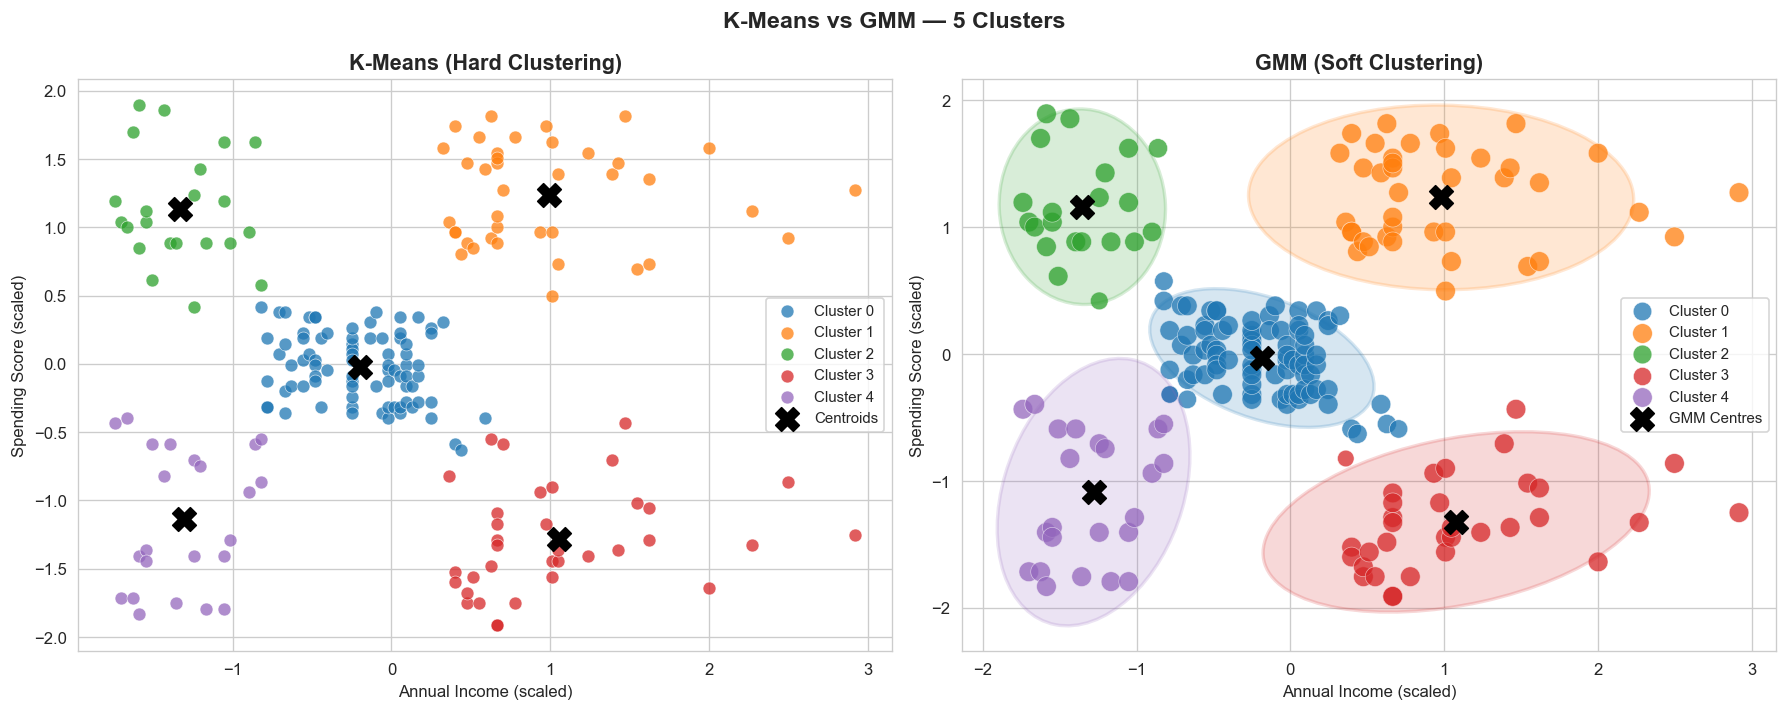

In [34]:
kmeans = KMeans(n_clusters=N_COMPONENTS, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)
df['KMeans_Cluster'] = kmeans_labels

print(f'K-Means Inertia: {kmeans.inertia_:.4f}')

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── K-Means ────────────────────────────────────────────────────────────────
for i in range(N_COMPONENTS):
    mask = kmeans_labels == i
    axes[0].scatter(X[mask, 0], X[mask, 1], color=palette[i], s=60,
                    alpha=0.75, edgecolors='white', linewidth=0.4,
                    label=f'Cluster {i}')
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                marker='X', s=200, c='black', zorder=5, label='Centroids')
axes[0].set_title('K-Means (Hard Clustering)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Annual Income (scaled)')
axes[0].set_ylabel('Spending Score (scaled)')
axes[0].legend(fontsize=9)

# ── GMM ────────────────────────────────────────────────────────────────────
for i in range(N_COMPONENTS):
    mask = gmm_labels == i
    axes[1].scatter(X[mask, 0], X[mask, 1], color=palette[i],
                    s=60 + 80*proba[mask, i],
                    alpha=0.75, edgecolors='white', linewidth=0.4,
                    label=f'Cluster {i}')
    draw_ellipse(axes[1], gmm.means_[i], gmm.covariances_[i], palette[i])
axes[1].scatter(gmm.means_[:, 0], gmm.means_[:, 1],
                marker='X', s=200, c='black', zorder=5, label='GMM Centres')
axes[1].set_title('GMM (Soft Clustering)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Annual Income (scaled)')
axes[1].set_ylabel('Spending Score (scaled)')
axes[1].legend(fontsize=9)

plt.suptitle(f'K-Means vs GMM — {N_COMPONENTS} Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 📐 Step 10: Evaluation Metrics

In [35]:
# GMM metrics
gmm_ll   = gmm.score(X) * len(X)
gmm_aic  = gmm.aic(X)
gmm_bic  = gmm.bic(X)
gmm_sil  = silhouette_score(X, gmm_labels)

# K-Means metrics
kmeans_sil = silhouette_score(X, kmeans_labels)

metrics_df = pd.DataFrame({
    'Metric'       : ['Log-Likelihood', 'AIC', 'BIC', 'Silhouette Score'],
    'GMM'          : [f'{gmm_ll:.2f}', f'{gmm_aic:.2f}', f'{gmm_bic:.2f}', f'{gmm_sil:.4f}'],
    'K-Means'      : ['N/A', 'N/A', 'N/A', f'{kmeans_sil:.4f}'],
    'Interpretation': [
        'Higher is better (model fit)',
        'Lower is better (penalises complexity)',
        'Lower is better (stricter penalty)',
        'Closer to 1 is better'
    ]
})

print('\n=== Evaluation Metrics ===')
metrics_df.style.set_properties(**{'text-align': 'left'}).hide(axis='index')


=== Evaluation Metrics ===


Metric,GMM,K-Means,Interpretation
Log-Likelihood,-452.50,N/A,Higher is better (model fit)
AIC,963.00,N/A,Lower is better (penalises complexity)
BIC,1058.65,N/A,Lower is better (stricter penalty)
Silhouette Score,0.5537,0.5547,Closer to 1 is better


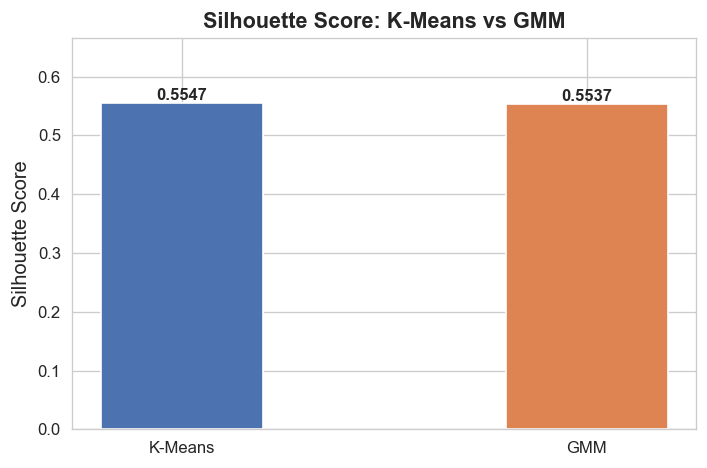

In [36]:
# Silhouette score comparison bar chart
fig, ax = plt.subplots(figsize=(6, 4))
models  = ['K-Means', 'GMM']
scores  = [kmeans_sil, gmm_sil]
colors  = ['#4C72B0', '#DD8452']

bars = ax.bar(models, scores, color=colors, edgecolor='white', width=0.4)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.4f}', ha='center', fontweight='bold')

ax.set_ylim(0, max(scores)*1.2)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score: K-Means vs GMM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔎 Step 11: Soft vs Hard Clustering Analysis

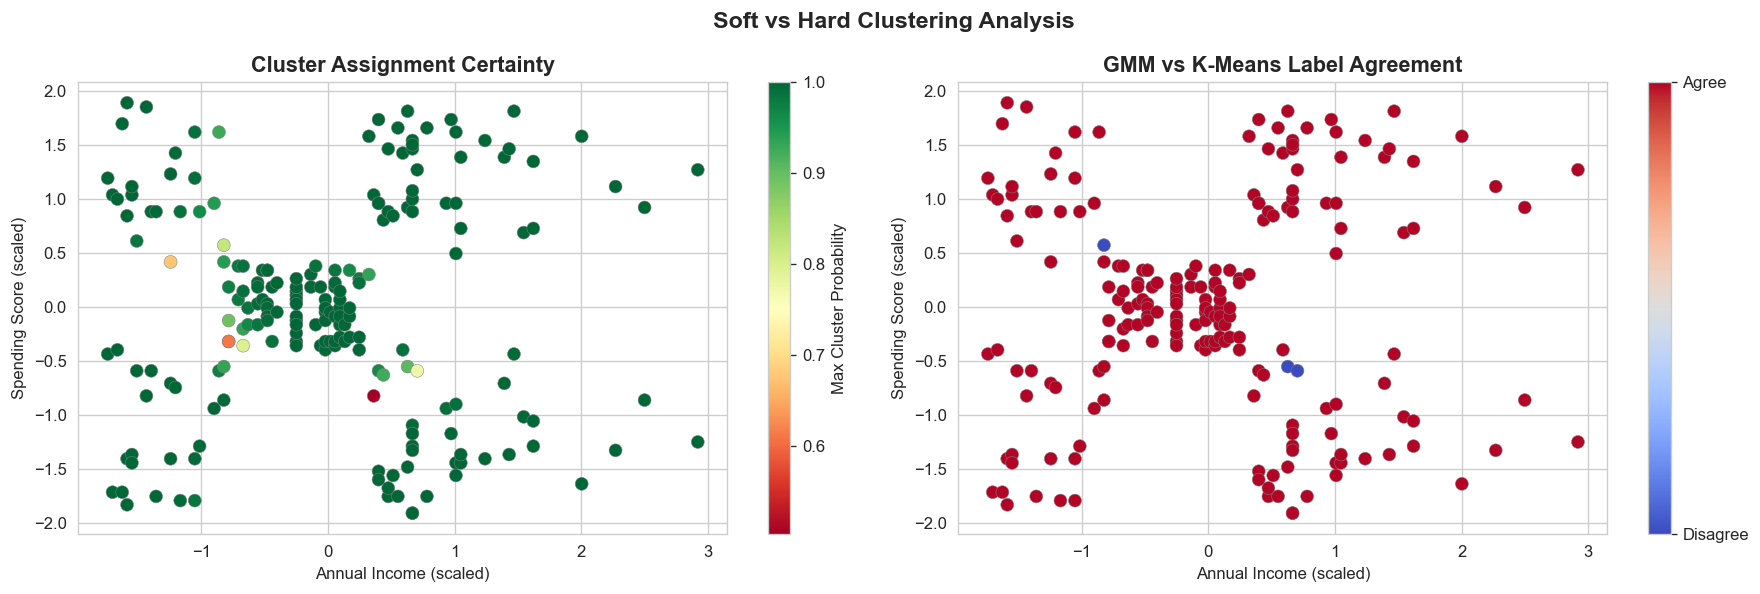


Overall label agreement between GMM and K-Means: 98.5%


In [37]:
# Uncertainty map — points coloured by max probability (certainty)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Max probability (certainty)
sc = axes[0].scatter(X[:, 0], X[:, 1], c=df['Max_Probability'],
                     cmap='RdYlGn', s=60, edgecolors='grey', linewidth=0.3)
plt.colorbar(sc, ax=axes[0], label='Max Cluster Probability')
axes[0].set_title('Cluster Assignment Certainty', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Annual Income (scaled)')
axes[0].set_ylabel('Spending Score (scaled)')

# Agreement between GMM and K-Means labels
# Remap K-Means labels to best match GMM labels
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

cm_mat = confusion_matrix(gmm_labels, kmeans_labels)
row_ind, col_ind = linear_sum_assignment(-cm_mat)
mapping = {c: r for r, c in zip(row_ind, col_ind)}
kmeans_remapped = np.array([mapping.get(l, l) for l in kmeans_labels])

agreement = (gmm_labels == kmeans_remapped).astype(int)
sc2 = axes[1].scatter(X[:, 0], X[:, 1], c=agreement,
                      cmap='coolwarm', s=60, edgecolors='grey', linewidth=0.3,
                      vmin=0, vmax=1)
cbar2 = plt.colorbar(sc2, ax=axes[1])
cbar2.set_ticks([0, 1])
cbar2.set_ticklabels(['Disagree', 'Agree'])
axes[1].set_title('GMM vs K-Means Label Agreement', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Annual Income (scaled)')
axes[1].set_ylabel('Spending Score (scaled)')

plt.suptitle('Soft vs Hard Clustering Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

agree_pct = agreement.mean() * 100
print(f'\nOverall label agreement between GMM and K-Means: {agree_pct:.1f}%')

## 📐 Step 12: Covariance Types — Spherical vs Full (Elliptical)

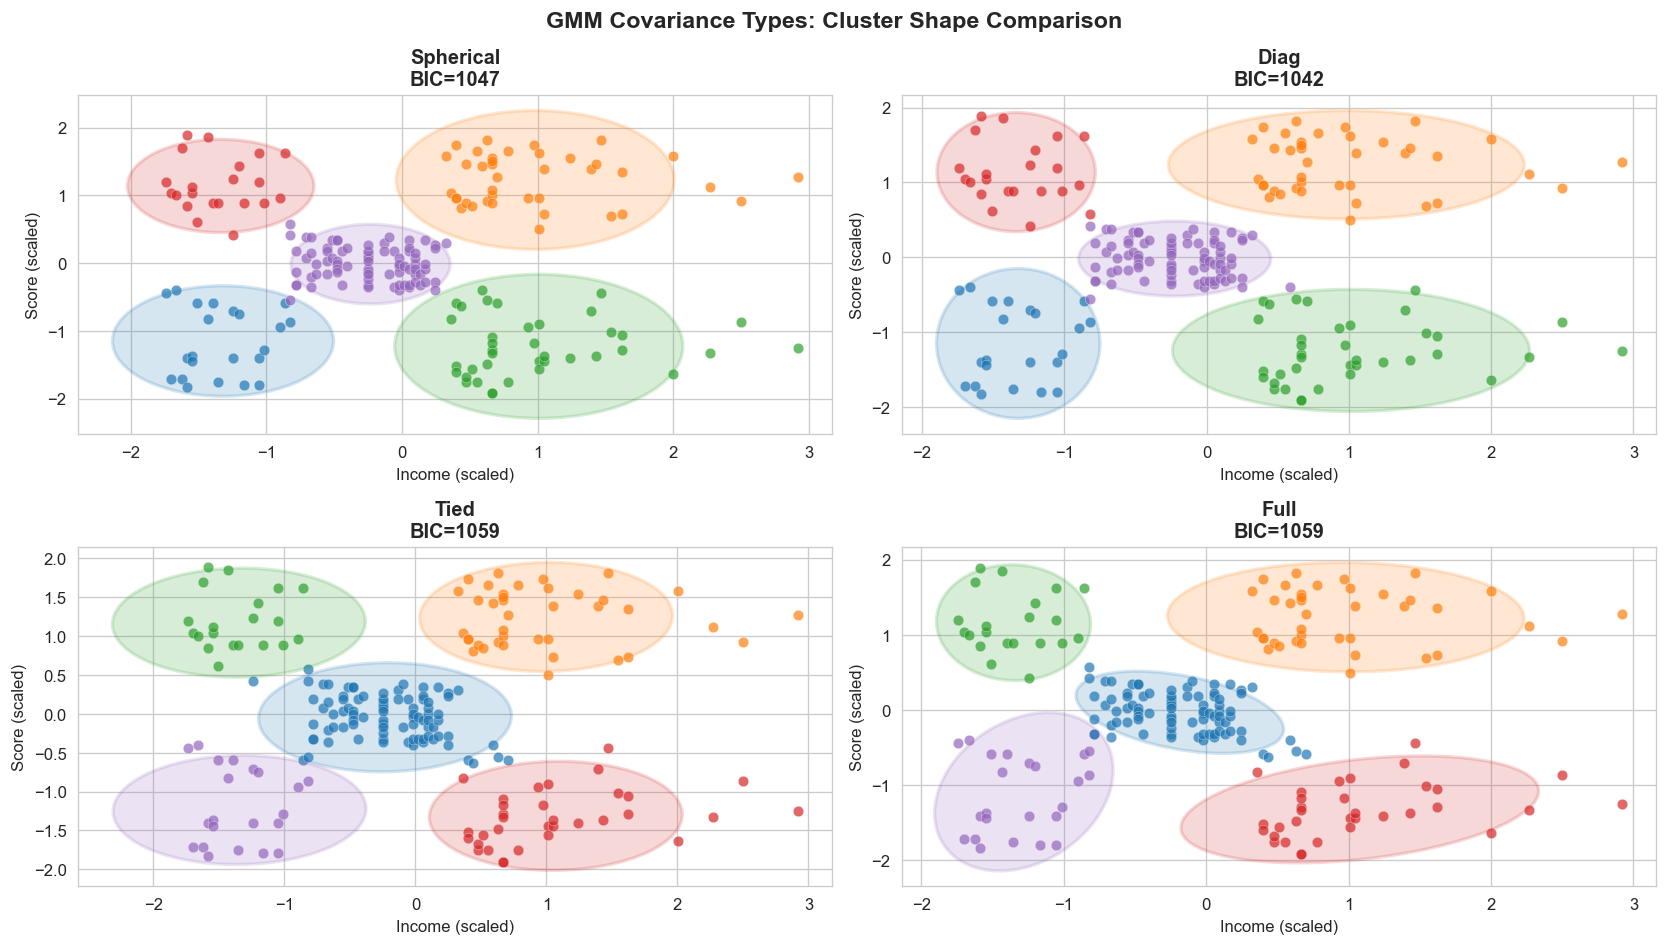

In [48]:
cov_types = ['spherical', 'diag', 'tied', 'full']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, (ax, ctype) in enumerate(zip(axes, cov_types)):
    g = GaussianMixture(n_components=N_COMPONENTS, covariance_type=ctype,
                        random_state=42, n_init=5)
    g.fit(X)
    labels = g.predict(X)
    
    for i in range(N_COMPONENTS):
        mask = labels == i
        ax.scatter(X[mask, 0], X[mask, 1], color=palette[i], s=40,
                   alpha=0.7, edgecolors='white', linewidth=0.3)
        
        # Build full covariance for ellipse drawing
        if ctype == 'full':
            cov = g.covariances_[i]
        elif ctype == 'tied':
            cov = g.covariances_
        elif ctype == 'diag':
            cov = np.diag(g.covariances_[i])
        else:  # spherical
            cov = np.eye(2) * g.covariances_[i]
        
        draw_ellipse(ax, g.means_[i], cov, palette[i])
    
    ax.set_title(f'{ctype.capitalize()}\nBIC={g.bic(X):.0f}', fontweight='bold')
    ax.set_xlabel('Income (scaled)')
    ax.set_ylabel('Score (scaled)')

# Hide unused subplots (since we only have 4 plots but grid has 6)
for j in range(len(cov_types), len(axes)):
    axes[j].axis('off')

plt.suptitle('GMM Covariance Types: Cluster Shape Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 📋 Step 13: Cluster Summary Statistics

In [39]:
summary = df.groupby('GMM_Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)','Max_Probability']].agg(
    ['mean','std','count']
).round(2)

print('=== GMM Cluster Summary ===')
display(summary)

print('\n=== GMM Component Weights ===')
for i, w in enumerate(gmm.weights_):
    print(f'  Cluster {i}: weight = {w:.4f}  ({w*100:.1f}% of data)')

=== GMM Cluster Summary ===


Age              Annual Income (k$)               \
              mean    std count               mean    std count   
GMM_Cluster                                                       
0            42.71  16.35    84              55.64   9.66    84   
1            32.69   3.73    39              86.54  16.31    39   
2            25.33   5.38    21              25.10   7.13    21   
3            40.45  11.31    33              88.82  16.70    33   
4            45.22  13.23    23              26.30   7.89    23   

            Spending Score (1-100)              Max_Probability              
                              mean    std count            mean   std count  
GMM_Cluster                                                                  
0                            49.37   6.98    84            0.97  0.07    84  
1                            82.13   9.36    39            1.00  0.00    39  
2                            80.05  10.25    21            0.97  0.07    21  
3                            16.00   9.10    33            0.98  0.09    33  
4                            20.91  13.02    23            0.99  0.01    23


=== GMM Component Weights ===
  Cluster 0: weight = 0.4133  (41.3% of data)
  Cluster 1: weight = 0.1967  (19.7% of data)
  Cluster 2: weight = 0.1035  (10.4% of data)
  Cluster 3: weight = 0.1655  (16.6% of data)
  Cluster 4: weight = 0.1209  (12.1% of data)


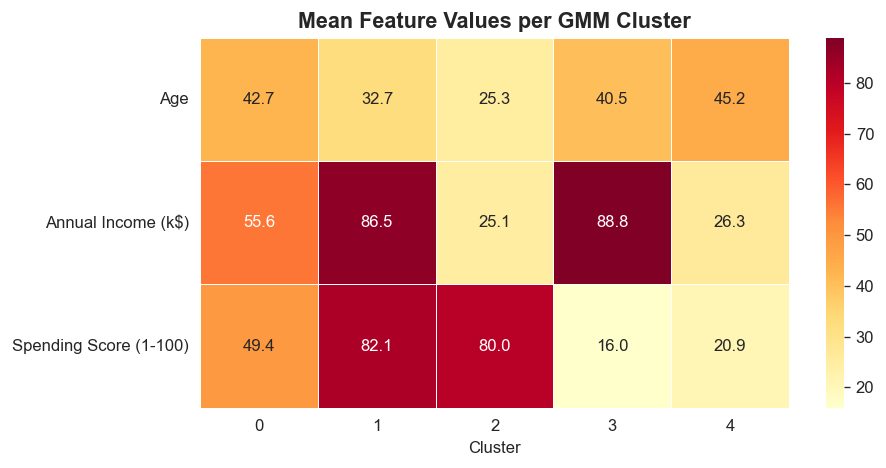

In [40]:
# Heatmap of mean cluster profiles
cluster_means = df.groupby('GMM_Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean()

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(cluster_means.T, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('Mean Feature Values per GMM Cluster', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

## ✅ Step 14: Summary & Conclusions

| Aspect | K-Means | GMM |
|---|---|---|
| Cluster type | Hard (each point → one cluster) | Soft (probabilities for all clusters) |
| Cluster shape | Spherical (Euclidean distance) | Elliptical (full covariance) |
| Output | Single label | Probability vector per point |
| Model selection | Elbow / Silhouette | AIC / BIC / Log-Likelihood |
| Overlapping clusters | ❌ Cannot represent | ✅ Naturally captured |
| Flexibility | Low | High |
| Computational cost | Lower | Higher |

### Key Takeaways
- **GMM** is a probabilistic generative model that uses **Expectation-Maximisation** to fit Gaussian distributions to data.
- **Soft clustering** allows boundary points to have meaningful partial membership in multiple clusters, unlike K-Means.
- **AIC / BIC** provide principled ways to choose the number of components, penalising over-complex models.
- The **full covariance** type allows GMM to detect elongated, rotated clusters that K-Means cannot capture.
- **Log-Likelihood** measures overall model fit; higher values indicate the model better explains the data.